# LIS 4369: Extensible Enterprise Solutions

## Assignment 3 - Health Care Analysis 2

**Developer:** Joshua Mann

**Program Requirements:**

1. Get
2. Clean
3. Prepare
4. Analyze
5. Visualize

**Note: MUST** use **conda** environment.

In [1]:
# 1. import necessary packages
import sys
import os
import pandas as pd
print(sys.version) # print python version
print (os.environ['CONDA_DEFAULT_ENV']) # print conda environment

3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]
testenv


In [2]:
# 2. get/read "cleaned" .csv patient data (use .csv from Assignment 2)
import time
start_time = time.time()

pd.read_csv("patients_clean.csv")

end_time = time.time()
print("\nRead .csv file (seconds) =", format((end_time - start_time), '.2f'))


Read .csv file (seconds) = 1.49


In [3]:
# 3. convert .csv file to .zip
import zipfile

zip_file_name = 'patients_clean_csv.zip'

start_time = time.time()
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zip:
    zip.write('patients_clean.csv')

end_time = time.time()
print("\nConvert .csv file to .zip file (seconds) =", format((end_time - start_time), '.2f'))


Convert .csv file to .zip file (seconds) = 8.13


In [4]:
# 4. get/read "cleaned" .zip patient data
start_time = time.time()

pd.read_csv('patients_clean_csv.zip')

end_time = time.time()
print("\nTime required to read .zip file (seconds) =", format((end_time - start_time), '.2f'))


Time required to read .zip file (seconds) = 2.16


In [5]:
# 5. convert DF to Excel file
df_patients = pd.read_csv("patients_clean.csv") # get/read .csv file into DF

start_time = time.time()
# convert DF To Excel file w/o added DF index column
df_patients.to_excel('patients_clean.xlsx',index=False)

end_time = time.time()
print("\nConvert DF to Excel file (minutes) =", format((end_time - start_time)/60, '.2f'))


Convert DF to Excel file (minutes) = 3.03


In [6]:
# 6. check DF type
type(df_patients)

pandas.DataFrame

In [7]:
# 7. get/read "cleaned" .xlsx patient data
start_time = time.time()

pd.read_excel('patients_clean.xlsx')

end_time = time.time()
print("\nRead Excel file (minutes) =", format((end_time - start_time)/60, '.2f'))


Read Excel file (minutes) = 2.58


In [8]:
# 8. convert .xlsx file to .zip
zip_file_name = 'patients_clean.xlsx.zip'

start_time = time.time()
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zip:
    zip.write('patients_clean.xlsx')

end_time = time.time()
print("\nConvert Excel file to .zip file (seconds) =", format((end_time - start_time), '.2f'))


Convert Excel file to .zip file (seconds) = 3.83


In [9]:
# 9. convert Excel file to .zip file with error-checking
# define .xlsx and .zip path/file names
xlsx_file_name = 'patients_clean.xlsx'
zip_file_name = 'patients_clean_xlsx_error_checking.zip'

# create ZipFile object in write mode ('w')
start_time = time.time()
try:
    with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zip:
        # add .xlsx file to ZIP archive
        zip.write(xlsx_file_name, os.path.basename(xlsx_file_name))
    print(f"Successfully zipped '{xlsx_file_name}' into '{zip_file_name}'")
# catch errors
except Exception as e:
    print(f"Error zipping file: {e}")

end_time = time.time()
print("\nConvert Excel file to .zip file (seconds) =", format((end_time - start_time), '.2f'))

Successfully zipped 'patients_clean.xlsx' into 'patients_clean_xlsx_error_checking.zip'

Convert Excel file to .zip file (seconds) = 3.82


In [15]:
# 10. get/read Excel file from .zip archive with error-checking
import io

def read_excel_from_zip(zip_filepath, excel_filename_in_zip):
    """
    reads Excel (.xlsx) file w/in .zip archive
    args:
        zip_filepath (str): path to .zip file
        excel_filename_in_zip (str): name of .xlsx file inside .zip file
    returns:
        pandas.DataFrame: data from Excel file
    """
    try:
        with zipfile.ZipFile(zip_filepath, 'r') as zf:
            # open Excel file w/in .zip archive
            with zf.open(excel_filename_in_zip) as excel_file:
                # read contents into BytesIO object for pandas to read
                excel_data = io.BytesIO(excel_file.read())
                # read Excel file data into pandas DataFrame
                df = pd.read_excel(excel_data)
                return df
    # catch errors
    except FileNotFoundError:
        print(f"Error: The file '{zip_filepath}' or '{excel_filename_in_zip}' was not found.")
        return None
    except KeyError:
        print(f"Error: The file '{excel_filename_in_zip}' not found inside '{zip_filepath}'.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

zip_file = 'patients_clean_xlsx.zip'
excel_file_in_zip = 'patients_clean.xlsx' # name of .xlsx file inside .zip file

start_time = time.time()

df = read_excel_from_zip(zip_file, excel_file_in_zip)

end_time = time.time()
print("\nRead Excel file in .zip archive (minutes) =", format((end_time - start_time)/60, '.2f'))


Read Excel file in .zip archive (minutes) = 8.36


In [16]:
# 11. indicate if successful
if df is not None:
    print("Successfully read Excel data:")

Successfully read Excel data:


In [17]:
# 12. display first 5 records
df.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Zip,Total_Cost,Registration_mins,Nursing_mins,Laboratory_mins,Consultation_mins,Pharmacy_mins
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262,68,55,60,90,104


In [18]:
# 13. display return type of value_counts() method
type(df['Gender'].value_counts())

pandas.Series

In [19]:
# 14. return gender count in desc. order
# note: value_counts(): returns Series with count of unique values (in desc. order) from DataFrame column (index represents unique values), NaN values excluded
df['Gender'].value_counts()

Gender
Male      500108
Female    499892
Name: count, dtype: int64

In [20]:
# 15. assign variable for plotting
patient_gender = df['Gender'].value_counts()

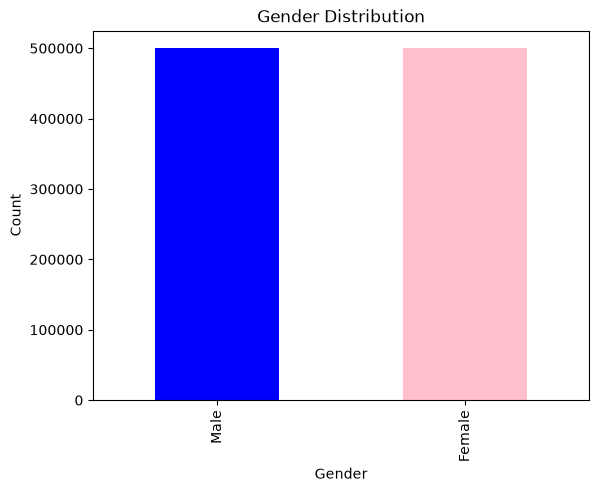

In [22]:
# 16. plot patient gender count using bar plot
import matplotlib.pyplot as plt

patient_gender.plot(kind='bar',color=['blue','pink'])
plt.title("Gender Distribution")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

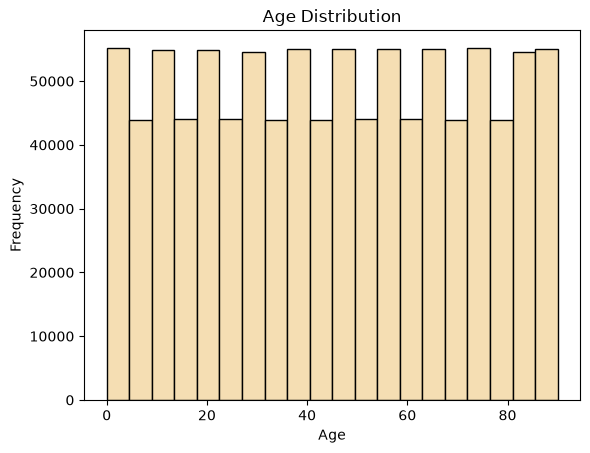

In [23]:
# 17. plot patient age distribution using histogram
plt.hist(df['Age'],bins=20,color='wheat',edgecolor='k')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [24]:
# 18. display max age
df['Age'].max()

np.int64(90)

In [25]:
# 19. display min age
df['Age'].min()

np.int64(0)

In [26]:
# 20. define bin edges: create bins based upon min/max ages
age_bins = [0,10,20,30,40,50,60,70,80,90]

In [27]:
# 21. segment ages into bins using cut() function, creates new column with age categories
# note: df['Age'] specifies data to be binned (i.e., 'Age' col) and bings=age_bins provides custom bin edges
# by default, right edge of each bin is inclusive (e.g., (0,10] includes 10)
df['Age_Range'] = pd.cut(df['Age'],bins=age_bins)

In [28]:
# 22. display first 5 records with new "Age_Range" col
df.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Zip,Total_Cost,Registration_mins,Nursing_mins,Laboratory_mins,Consultation_mins,Pharmacy_mins,Age_Range
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274,33,105,101,28,112,"(60, 70]"
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430,46,75,84,102,36,"(60, 70]"
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836,107,81,5,77,36,"(60, 70]"
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250,66,31,101,35,92,"(0, 10]"
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262,68,55,60,90,104,"(20, 30]"


In [29]:
# 23. return age range count in desc. order
df['Age_Range'].value_counts()

Age_Range
(50, 60]    110259
(70, 80]    110051
(60, 70]    110039
(0, 10]     110025
(40, 50]    109960
(10, 20]    109930
(30, 40]    109723
(20, 30]    109577
(80, 90]    109515
Name: count, dtype: int64

In [31]:
# 24. return and display DataFrame column sorted by index
age_distribution = df['Age_Range'].value_counts().sort_index()
age_distribution

Age_Range
(0, 10]     110025
(10, 20]    109930
(20, 30]    109577
(30, 40]    109723
(40, 50]    109960
(50, 60]    110259
(60, 70]    110039
(70, 80]    110051
(80, 90]    109515
Name: count, dtype: int64

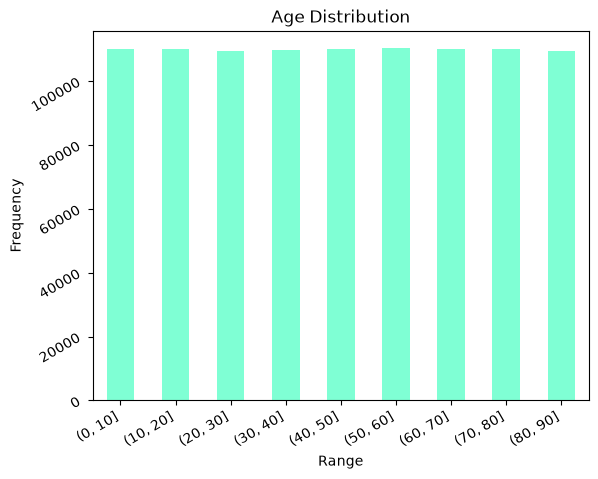

In [32]:
# 25. display age distribution, based upon age bins
# note: "ha" = horizontal alignment
age_distribution.plot(kind='bar',color='aquamarine')
plt.title('Age Distribution')
plt.xlabel('Range')
plt.ylabel('Frequency')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=30)
plt.show()